# Condition Number Analysis: Marchenko-Pastur Denoising

This notebook investigates the condition number of sample covariance matrices after applying Marchenko-Pastur (MP) denoising as a function of sample size.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import sys
sys.path.append('../')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tqdm import tqdm

In [4]:
from src.datasets import build_true_matrix, simulate_from_covariance_mean
from src.models.rmt.CleanseMatrix import CleanseMatrix
from src.models.rmt.utils import covariance2correlation

## 1. Generate True Covariance Matrix

In [5]:
# Set random seed for reproducibility
np.random.seed(0)

# Parameters for the true covariance matrix
number_blocks = 5
block_size = 10
block_correlation = 0.5

# Build the true covariance matrix
true_mu, true_covariance = build_true_matrix(
    number_blocks=number_blocks,
    block_size=block_size,
    block_correlation=block_correlation
)

print(f"Covariance matrix shape: {true_covariance.shape}")
print(f"Mean vector shape: {true_mu.shape}")

Covariance matrix shape: (50, 50)
Mean vector shape: (50, 1)


## 2. Compute Condition Number of True Covariance (cond_0)

In [6]:
# Compute the condition number of the true covariance matrix
cond_0 = np.linalg.cond(true_covariance)
print(f"Condition number of true covariance (cond_0): {cond_0:.4f}")

Condition number of true covariance (cond_0): 91.0112


## 3. Generate Samples and Apply MP Denoising

For each sample size, we will:
1. Generate samples from the true covariance
2. Compute the sample covariance matrix
3. Apply Marchenko-Pastur denoising
4. Compute the condition number of the denoised matrix

In [7]:
# Define sample sizes to test
sample_sizes = list(range(100, 1000, 100)) + list(range(1000, 10001, 500))

# Number of replications for each sample size
num_replications = 200

print(f"Testing {len(sample_sizes)} sample sizes: {sample_sizes}")
print(f"Running {num_replications} replications for each sample size")
print(f"Total experiments: {len(sample_sizes) * num_replications}")

Testing 28 sample sizes: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000]
Running 200 replications for each sample size
Total experiments: 5600


In [8]:
# Storage for results
results = {
    'sample_size': [],
    'cond_n_median': [],
    'cond_n_q25': [],
    'cond_n_q75': [],
    'cond_n_mean': [],
    'cond_n_std': [],
    'cond_mp_median': [],  # Condition number after MP denoising
    'cond_mp_q25': [],
    'cond_mp_q75': [],
    'cond_mp_mean': [],
    'cond_mp_std': [],
    'ratio_raw_median': [],  # Ratio for raw sample covariance
    'ratio_raw_q25': [],
    'ratio_raw_q75': [],
    'ratio_mp_median': [],  # Ratio for MP denoised covariance
    'ratio_mp_q25': [],
    'ratio_mp_q75': [],
    'num_signal_factors_median': [],  # Number of signal factors identified by MP
    'num_signal_factors_mean': []
}

# Run the experiment with replications
print("Generating samples, applying MP denoising, and computing condition numbers...")
print("This may take a few minutes...\n")

for n in tqdm(sample_sizes, desc="Sample sizes"):
    # Storage for replications
    cond_n_replications = []
    cond_mp_replications = []
    ratio_raw_replications = []
    ratio_mp_replications = []
    num_signal_factors_replications = []
    
    # Run multiple replications for this sample size
    for r in range(num_replications):
        # Generate n samples from the true covariance
        data, sample_mu, sample_covariance = simulate_from_covariance_mean(
            true_mu=true_mu,
            true_covariance=true_covariance,
            number_of_observations=n
        )
        
        # Compute condition number of raw sample covariance
        cond_n = np.linalg.cond(sample_covariance)
        ratio_raw = cond_n / cond_0
        
        # Apply MP denoising to the sample correlation matrix
        # Convert covariance to correlation for MP denoising
        sample_correlation = covariance2correlation(sample_covariance)
        
        # Initialize CleanseMatrix with MP denoising (no shrinkage, no detoning)
        try:
            cleanser = CleanseMatrix(
                use_shrinkage=False,
                shrinkage_regularizer=0.0,
                detone=False,
                market_components_max_index=1,
                verbose=False,  # Suppress verbose output
                grid_size=500,  # Reduced for speed
                cv=20,  # Reduced for speed
                bandwidth_grid_size=50,  # Reduced for speed
                q_grid_size=10  # Reduced for speed
            )
            
            # Fit and denoise
            cleanser.fit(sample_correlation)
            denoised_correlation = cleanser.cleansed_matrix
            
            # Compute condition number of denoised matrix
            cond_mp = np.linalg.cond(denoised_correlation)
            ratio_mp = cond_mp / cond_0
            
            # Store number of signal factors
            num_signal_factors = cleanser.estimated_number_signal_factors
            
        except Exception as e:
            # If MP denoising fails, use NaN
            cond_mp = np.nan
            ratio_mp = np.nan
            num_signal_factors = np.nan
        
        # Store replication results
        cond_n_replications.append(cond_n)
        cond_mp_replications.append(cond_mp)
        ratio_raw_replications.append(ratio_raw)
        ratio_mp_replications.append(ratio_mp)
        num_signal_factors_replications.append(num_signal_factors)
    
    # Remove NaN values for statistics
    cond_mp_valid = [x for x in cond_mp_replications if not np.isnan(x)]
    ratio_mp_valid = [x for x in ratio_mp_replications if not np.isnan(x)]
    num_signal_factors_valid = [x for x in num_signal_factors_replications if not np.isnan(x)]
    
    # Compute statistics across replications
    results['sample_size'].append(n)
    
    # Raw sample covariance statistics
    results['cond_n_median'].append(np.median(cond_n_replications))
    results['cond_n_q25'].append(np.percentile(cond_n_replications, 25))
    results['cond_n_q75'].append(np.percentile(cond_n_replications, 75))
    results['cond_n_mean'].append(np.mean(cond_n_replications))
    results['cond_n_std'].append(np.std(cond_n_replications))
    
    results['ratio_raw_median'].append(np.median(ratio_raw_replications))
    results['ratio_raw_q25'].append(np.percentile(ratio_raw_replications, 25))
    results['ratio_raw_q75'].append(np.percentile(ratio_raw_replications, 75))
    
    # MP denoised statistics
    if len(cond_mp_valid) > 0:
        results['cond_mp_median'].append(np.median(cond_mp_valid))
        results['cond_mp_q25'].append(np.percentile(cond_mp_valid, 25))
        results['cond_mp_q75'].append(np.percentile(cond_mp_valid, 75))
        results['cond_mp_mean'].append(np.mean(cond_mp_valid))
        results['cond_mp_std'].append(np.std(cond_mp_valid))
        
        results['ratio_mp_median'].append(np.median(ratio_mp_valid))
        results['ratio_mp_q25'].append(np.percentile(ratio_mp_valid, 25))
        results['ratio_mp_q75'].append(np.percentile(ratio_mp_valid, 75))
        
        results['num_signal_factors_median'].append(np.median(num_signal_factors_valid))
        results['num_signal_factors_mean'].append(np.mean(num_signal_factors_valid))
    else:
        results['cond_mp_median'].append(np.nan)
        results['cond_mp_q25'].append(np.nan)
        results['cond_mp_q75'].append(np.nan)
        results['cond_mp_mean'].append(np.nan)
        results['cond_mp_std'].append(np.nan)
        results['ratio_mp_median'].append(np.nan)
        results['ratio_mp_q25'].append(np.nan)
        results['ratio_mp_q75'].append(np.nan)
        results['num_signal_factors_median'].append(np.nan)
        results['num_signal_factors_mean'].append(np.nan)

# Convert to DataFrame for easier analysis
results_df = pd.DataFrame(results)
print("\nFirst few results:")
print(results_df[['sample_size', 'cond_n_median', 'cond_mp_median', 'ratio_raw_median', 'ratio_mp_median', 'num_signal_factors_median']].head())
print("\nLast few results:")
print(results_df[['sample_size', 'cond_n_median', 'cond_mp_median', 'ratio_raw_median', 'ratio_mp_median', 'num_signal_factors_median']].tail())

Generating samples, applying MP denoising, and computing condition numbers...
This may take a few minutes...



Sample sizes: 100%|█████████████████████████████| 28/28 [14:57<00:00, 32.05s/it]


First few results:
   sample_size  cond_n_median  cond_mp_median  ratio_raw_median  \
0          100     367.169488       11.749224          4.034334   
1          200     166.308999       10.721847          1.827347   
2          300     135.654371       13.547601          1.490524   
3          400     122.170876       13.579695          1.342372   
4          500     115.317884       13.263886          1.267074   

   ratio_mp_median  num_signal_factors_median  
0         0.129096                        2.0  
1         0.117808                        2.0  
2         0.148856                        5.0  
3         0.149209                        5.0  
4         0.145739                        5.0  

Last few results:
    sample_size  cond_n_median  cond_mp_median  ratio_raw_median  \
23         8000      92.228680             1.0          1.013377   
24         8500      92.195468             1.0          1.013012   
25         9000      92.673933             1.0          1.018270  

## 4. Visualize the Results

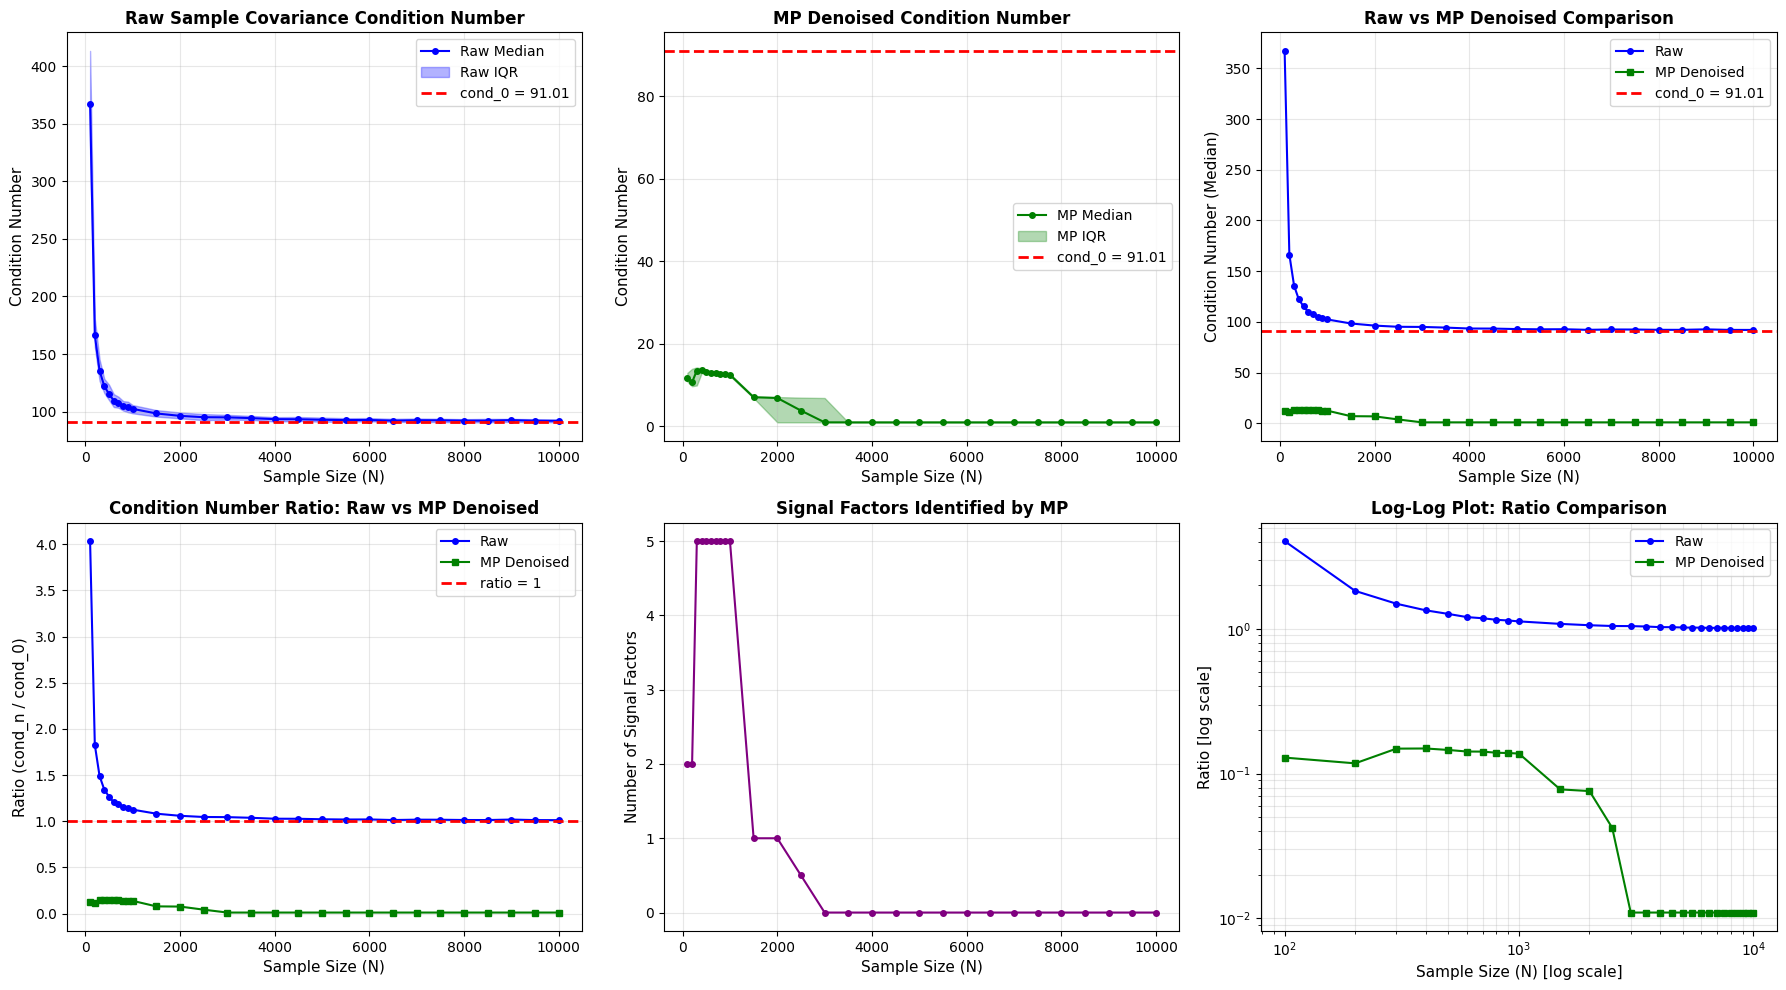

In [9]:
# Plot the condition numbers with median and quartiles
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Raw cond_n vs sample size
axes[0, 0].plot(results_df['sample_size'], results_df['cond_n_median'], 'o-', markersize=4, label='Raw Median', color='blue')
axes[0, 0].fill_between(results_df['sample_size'], 
                         results_df['cond_n_q25'], 
                         results_df['cond_n_q75'], 
                         alpha=0.3, color='blue', label='Raw IQR')
axes[0, 0].axhline(y=cond_0, color='r', linestyle='--', label=f'cond_0 = {cond_0:.2f}', linewidth=2)
axes[0, 0].set_xlabel('Sample Size (N)', fontsize=11)
axes[0, 0].set_ylabel('Condition Number', fontsize=11)
axes[0, 0].set_title('Raw Sample Covariance Condition Number', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: MP denoised cond_n vs sample size
axes[0, 1].plot(results_df['sample_size'], results_df['cond_mp_median'], 'o-', markersize=4, label='MP Median', color='green')
axes[0, 1].fill_between(results_df['sample_size'], 
                         results_df['cond_mp_q25'], 
                         results_df['cond_mp_q75'], 
                         alpha=0.3, color='green', label='MP IQR')
axes[0, 1].axhline(y=cond_0, color='r', linestyle='--', label=f'cond_0 = {cond_0:.2f}', linewidth=2)
axes[0, 1].set_xlabel('Sample Size (N)', fontsize=11)
axes[0, 1].set_ylabel('Condition Number', fontsize=11)
axes[0, 1].set_title('MP Denoised Condition Number', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Comparison of raw vs MP denoised
axes[0, 2].plot(results_df['sample_size'], results_df['cond_n_median'], 'o-', markersize=4, label='Raw', color='blue')
axes[0, 2].plot(results_df['sample_size'], results_df['cond_mp_median'], 's-', markersize=4, label='MP Denoised', color='green')
axes[0, 2].axhline(y=cond_0, color='r', linestyle='--', label=f'cond_0 = {cond_0:.2f}', linewidth=2)
axes[0, 2].set_xlabel('Sample Size (N)', fontsize=11)
axes[0, 2].set_ylabel('Condition Number (Median)', fontsize=11)
axes[0, 2].set_title('Raw vs MP Denoised Comparison', fontsize=12, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Ratio comparison
axes[1, 0].plot(results_df['sample_size'], results_df['ratio_raw_median'], 'o-', markersize=4, label='Raw', color='blue')
axes[1, 0].plot(results_df['sample_size'], results_df['ratio_mp_median'], 's-', markersize=4, label='MP Denoised', color='green')
axes[1, 0].axhline(y=1, color='r', linestyle='--', label='ratio = 1', linewidth=2)
axes[1, 0].set_xlabel('Sample Size (N)', fontsize=11)
axes[1, 0].set_ylabel('Ratio (cond_n / cond_0)', fontsize=11)
axes[1, 0].set_title('Condition Number Ratio: Raw vs MP Denoised', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Number of signal factors identified by MP
axes[1, 1].plot(results_df['sample_size'], results_df['num_signal_factors_median'], 'o-', markersize=4, color='purple')
axes[1, 1].set_xlabel('Sample Size (N)', fontsize=11)
axes[1, 1].set_ylabel('Number of Signal Factors', fontsize=11)
axes[1, 1].set_title('Signal Factors Identified by MP', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Log-log plot for ratio comparison
axes[1, 2].loglog(results_df['sample_size'], results_df['ratio_raw_median'], 'o-', markersize=4, label='Raw', color='blue')
axes[1, 2].loglog(results_df['sample_size'], results_df['ratio_mp_median'], 's-', markersize=4, label='MP Denoised', color='green')
axes[1, 2].set_xlabel('Sample Size (N) [log scale]', fontsize=11)
axes[1, 2].set_ylabel('Ratio [log scale]', fontsize=11)
axes[1, 2].set_title('Log-Log Plot: Ratio Comparison', fontsize=12, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 5. Power Law Analysis for MP Denoised Covariance

In [10]:
from scipy.optimize import curve_fit

def power_law(x, a, b):
    return a * np.power(x, b)

# Filter out NaN values for fitting
valid_mask = ~results_df['ratio_mp_median'].isna()
sample_sizes_valid = results_df['sample_size'][valid_mask].values
ratio_mp_valid = results_df['ratio_mp_median'][valid_mask].values
ratio_raw_valid = results_df['ratio_raw_median'][valid_mask].values

# Fit power law for MP denoised
if len(ratio_mp_valid) > 0:
    params_mp, covariance_mp = curve_fit(
        power_law,
        sample_sizes_valid,
        ratio_mp_valid,
        p0=[1, -0.5]
    )
    a_mp, b_mp = params_mp
    
    print(f"Power Law Fit for MP Denoised (using median across {num_replications} runs):")
    print(f"  ratio_mp_median = {a_mp:.4f} * N^{b_mp:.4f}")
    print(f"\nParameter uncertainties:")
    print(f"  a: {np.sqrt(covariance_mp[0, 0]):.4f}")
    print(f"  b: {np.sqrt(covariance_mp[1, 1]):.4f}")
    
    # Compute R-squared
    fitted_mp = power_law(sample_sizes_valid, a_mp, b_mp)
    residuals_mp = ratio_mp_valid - fitted_mp
    ss_res_mp = np.sum(residuals_mp**2)
    ss_tot_mp = np.sum((ratio_mp_valid - np.mean(ratio_mp_valid))**2)
    r_squared_mp = 1 - (ss_res_mp / ss_tot_mp)
    
    print(f"\nGoodness of Fit (MP):")
    print(f"  R-squared: {r_squared_mp:.4f}")
    print(f"  RMSE: {np.sqrt(np.mean(residuals_mp**2)):.4f}")

# Fit power law for raw covariance
params_raw, covariance_raw = curve_fit(
    power_law,
    sample_sizes_valid,
    ratio_raw_valid,
    p0=[1, -0.5]
)
a_raw, b_raw = params_raw

print(f"\n{'='*60}")
print(f"Power Law Fit for Raw Sample Covariance (using median across {num_replications} runs):")
print(f"  ratio_raw_median = {a_raw:.4f} * N^{b_raw:.4f}")
print(f"\nParameter uncertainties:")
print(f"  a: {np.sqrt(covariance_raw[0, 0]):.4f}")
print(f"  b: {np.sqrt(covariance_raw[1, 1]):.4f}")

# Compute R-squared
fitted_raw = power_law(sample_sizes_valid, a_raw, b_raw)
residuals_raw = ratio_raw_valid - fitted_raw
ss_res_raw = np.sum(residuals_raw**2)
ss_tot_raw = np.sum((ratio_raw_valid - np.mean(ratio_raw_valid))**2)
r_squared_raw = 1 - (ss_res_raw / ss_tot_raw)

print(f"\nGoodness of Fit (Raw):")
print(f"  R-squared: {r_squared_raw:.4f}")
print(f"  RMSE: {np.sqrt(np.mean(residuals_raw**2)):.4f}")

Power Law Fit for MP Denoised (using median across 200 runs):
  ratio_mp_median = 1.3175 * N^-0.4086

Parameter uncertainties:
  a: 0.5758
  b: 0.0698

Goodness of Fit (MP):
  R-squared: 0.6415
  RMSE: 0.0358

Power Law Fit for Raw Sample Covariance (using median across 200 runs):
  ratio_raw_median = 9.8235 * N^-0.2837

Parameter uncertainties:
  a: 2.6511
  b: 0.0401

Goodness of Fit (Raw):
  R-squared: 0.5826
  RMSE: 0.3677


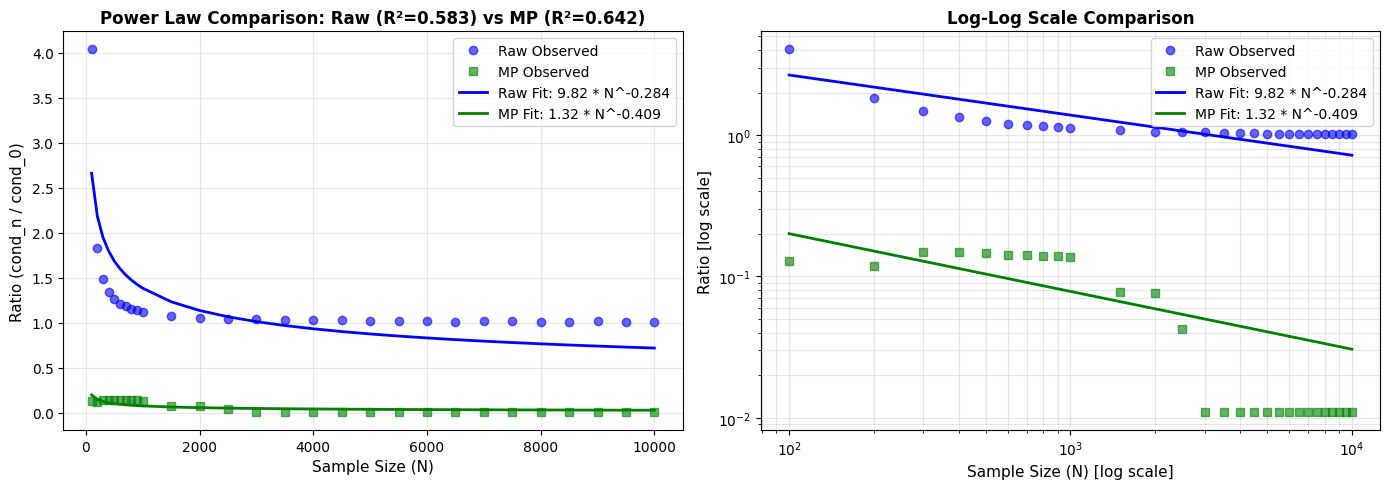

In [11]:
# Visualize the power law fits
if len(ratio_mp_valid) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Linear scale
    axes[0].plot(sample_sizes_valid, ratio_raw_valid, 'o', label='Raw Observed', markersize=6, color='blue', alpha=0.6)
    axes[0].plot(sample_sizes_valid, ratio_mp_valid, 's', label='MP Observed', markersize=6, color='green', alpha=0.6)
    axes[0].plot(sample_sizes_valid, fitted_raw, '-', 
                 label=f'Raw Fit: {a_raw:.2f} * N^{b_raw:.3f}', linewidth=2, color='blue')
    axes[0].plot(sample_sizes_valid, fitted_mp, '-', 
                 label=f'MP Fit: {a_mp:.2f} * N^{b_mp:.3f}', linewidth=2, color='green')
    axes[0].set_xlabel('Sample Size (N)', fontsize=11)
    axes[0].set_ylabel('Ratio (cond_n / cond_0)', fontsize=11)
    axes[0].set_title(f'Power Law Comparison: Raw (R²={r_squared_raw:.3f}) vs MP (R²={r_squared_mp:.3f})', 
                      fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Log-log scale
    axes[1].loglog(sample_sizes_valid, ratio_raw_valid, 'o', label='Raw Observed', markersize=6, color='blue', alpha=0.6)
    axes[1].loglog(sample_sizes_valid, ratio_mp_valid, 's', label='MP Observed', markersize=6, color='green', alpha=0.6)
    axes[1].loglog(sample_sizes_valid, fitted_raw, '-', 
                   label=f'Raw Fit: {a_raw:.2f} * N^{b_raw:.3f}', linewidth=2, color='blue')
    axes[1].loglog(sample_sizes_valid, fitted_mp, '-', 
                   label=f'MP Fit: {a_mp:.2f} * N^{b_mp:.3f}', linewidth=2, color='green')
    axes[1].set_xlabel('Sample Size (N) [log scale]', fontsize=11)
    axes[1].set_ylabel('Ratio [log scale]', fontsize=11)
    axes[1].set_title('Log-Log Scale Comparison', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, which='both')
    
    plt.tight_layout()
    plt.show()

## 6. Statistical Tests for Power Law

In [12]:
from scipy.stats import linregress

# Linear regression on log-transformed data for MP denoised
if len(ratio_mp_valid) > 0:
    log_N = np.log(sample_sizes_valid)
    log_ratio_mp = np.log(ratio_mp_valid)
    log_ratio_raw = np.log(ratio_raw_valid)
    
    # MP denoised regression
    slope_mp, intercept_mp, r_value_mp, p_value_mp, std_err_mp = linregress(log_N, log_ratio_mp)
    
    print("="*60)
    print("LINEAR REGRESSION ON LOG-TRANSFORMED DATA (MP DENOISED)")
    print("="*60)
    print(f"Using median ratios across {num_replications} replications\n")
    print(f"  log(ratio_mp_median) = {intercept_mp:.4f} + {slope_mp:.4f} * log(N)")
    print(f"  Which implies: ratio_mp_median = {np.exp(intercept_mp):.4f} * N^{slope_mp:.4f}")
    print(f"\n  R-squared: {r_value_mp**2:.4f}")
    print(f"  p-value: {p_value_mp:.6f}")
    print(f"  Standard error: {std_err_mp:.4f}")
    
    if p_value_mp < 0.001:
        print(f"\nThe relationship is highly significant (p < 0.001)")
    elif p_value_mp < 0.05:
        print(f"\nThe relationship is significant (p < 0.05)")
    else:
        print(f"\nThe relationship is not significant (p >= 0.05)")
    
    # Raw covariance regression
    slope_raw, intercept_raw, r_value_raw, p_value_raw, std_err_raw = linregress(log_N, log_ratio_raw)
    
    print("\n" + "="*60)
    print("LINEAR REGRESSION ON LOG-TRANSFORMED DATA (RAW)")
    print("="*60)
    print(f"Using median ratios across {num_replications} replications\n")
    print(f"  log(ratio_raw_median) = {intercept_raw:.4f} + {slope_raw:.4f} * log(N)")
    print(f"  Which implies: ratio_raw_median = {np.exp(intercept_raw):.4f} * N^{slope_raw:.4f}")
    print(f"\n  R-squared: {r_value_raw**2:.4f}")
    print(f"  p-value: {p_value_raw:.6f}")
    print(f"  Standard error: {std_err_raw:.4f}")

LINEAR REGRESSION ON LOG-TRANSFORMED DATA (MP DENOISED)
Using median ratios across 200 replications

  log(ratio_mp_median) = 2.9786 + -0.8344 * log(N)
  Which implies: ratio_mp_median = 19.6604 * N^-0.8344

  R-squared: 0.8221
  p-value: 0.000000
  Standard error: 0.0761

The relationship is highly significant (p < 0.001)

LINEAR REGRESSION ON LOG-TRANSFORMED DATA (RAW)
Using median ratios across 200 replications

  log(ratio_raw_median) = 1.4107 + -0.1646 * log(N)
  Which implies: ratio_raw_median = 4.0986 * N^-0.1646

  R-squared: 0.6066
  p-value: 0.000001
  Standard error: 0.0260


## 7. Summary Statistics and Comparison

In [13]:
print("="*60)
print("SUMMARY OF RESULTS: MP DENOISING ANALYSIS")
print("="*60)
print(f"\nTrue covariance condition number (cond_0): {cond_0:.4f}")
print(f"\nExperimental Design:")
print(f"  Number of sample sizes tested: {len(sample_sizes)}")
print(f"  Sample size range: {min(sample_sizes)} to {max(sample_sizes)}")
print(f"  Replications per sample size: {num_replications}")
print(f"  Total experiments: {len(sample_sizes) * num_replications}")

print(f"\n{'='*60}")
print("RAW SAMPLE COVARIANCE STATISTICS")
print("="*60)
print(f"Condition number (median across replications):")
print(f"  Min: {results_df['cond_n_median'].min():.4f}")
print(f"  Max: {results_df['cond_n_median'].max():.4f}")
print(f"  Mean: {results_df['cond_n_median'].mean():.4f}")
print(f"\nRatio (median cond_n / cond_0):")
print(f"  Min: {results_df['ratio_raw_median'].min():.4f}")
print(f"  Max: {results_df['ratio_raw_median'].max():.4f}")
print(f"  Final (N={max(sample_sizes)}): {results_df['ratio_raw_median'].iloc[-1]:.4f}")

print(f"\n{'='*60}")
print("MP DENOISED COVARIANCE STATISTICS")
print("="*60)
valid_mp = results_df['cond_mp_median'].dropna()
if len(valid_mp) > 0:
    print(f"Condition number (median across replications):")
    print(f"  Min: {valid_mp.min():.4f}")
    print(f"  Max: {valid_mp.max():.4f}")
    print(f"  Mean: {valid_mp.mean():.4f}")
    
    valid_ratio_mp = results_df['ratio_mp_median'].dropna()
    print(f"\nRatio (median cond_mp / cond_0):")
    print(f"  Min: {valid_ratio_mp.min():.4f}")
    print(f"  Max: {valid_ratio_mp.max():.4f}")
    print(f"  Final (N={max(sample_sizes)}): {results_df['ratio_mp_median'].iloc[-1]:.4f}")
    
    print(f"\nSignal factors identified (median):")
    valid_factors = results_df['num_signal_factors_median'].dropna()
    print(f"  Min: {valid_factors.min():.0f}")
    print(f"  Max: {valid_factors.max():.0f}")
    print(f"  Mean: {valid_factors.mean():.2f}")
    
    print(f"\n{'='*60}")
    print("IMPROVEMENT FROM MP DENOISING")
    print("="*60)
    improvement = ((results_df['ratio_raw_median'] - results_df['ratio_mp_median']) / results_df['ratio_raw_median'] * 100).dropna()
    print(f"Average improvement in ratio: {improvement.mean():.2f}%")
    print(f"Max improvement in ratio: {improvement.max():.2f}%")
    print(f"Min improvement in ratio: {improvement.min():.2f}%")
    
    print(f"\n{'='*60}")
    print("POWER LAW COMPARISON")
    print("="*60)
    print(f"Raw covariance: ratio = {a_raw:.4f} * N^{b_raw:.4f} (R² = {r_squared_raw:.4f})")
    print(f"MP denoised: ratio = {a_mp:.4f} * N^{b_mp:.4f} (R² = {r_squared_mp:.4f})")
    print(f"\nExponent comparison:")
    print(f"  Raw: {b_raw:.4f}")
    print(f"  MP:  {b_mp:.4f}")
    print(f"  Difference: {abs(b_mp - b_raw):.4f}")
else:
    print("No valid MP denoising results")

SUMMARY OF RESULTS: MP DENOISING ANALYSIS

True covariance condition number (cond_0): 91.0112

Experimental Design:
  Number of sample sizes tested: 28
  Sample size range: 100 to 10000
  Replications per sample size: 200
  Total experiments: 5600

RAW SAMPLE COVARIANCE STATISTICS
Condition number (median across replications):
  Min: 92.0927
  Max: 367.1695
  Mean: 111.3909

Ratio (median cond_n / cond_0):
  Min: 1.0119
  Max: 4.0343
  Final (N=10000): 1.0119

MP DENOISED COVARIANCE STATISTICS
Condition number (median across replications):
  Min: 1.0000
  Max: 13.5797
  Mean: 5.6932

Ratio (median cond_mp / cond_0):
  Min: 0.0110
  Max: 0.1492
  Final (N=10000): 0.0110

Signal factors identified (median):
  Min: 0
  Max: 5
  Mean: 1.66

IMPROVEMENT FROM MP DENOISING
Average improvement in ratio: 95.11%
Max improvement in ratio: 98.95%
Min improvement in ratio: 87.77%

POWER LAW COMPARISON
Raw covariance: ratio = 9.8235 * N^-0.2837 (R² = 0.5826)
MP denoised: ratio = 1.3175 * N^-0.4086 (

In [14]:
# Save results
results_df.to_csv('mp_condition_number_results.csv', index=False)
print("\n" + "="*60)
print("Results saved to 'mp_condition_number_results.csv'")
print("="*60)


Results saved to 'mp_condition_number_results.csv'
